# 📌 1. Introduction & Objective

## Benchmarking CNN Model for Text Classification

### 📌 Objective  
In this notebook, we **attempt to replicate the official benchmark CNN model** from the Rakuten Challenge,  
based solely on the **`designation` field** (product titles).  
This setup will serve as a **baseline** to compare more advanced text models in the upcoming experiments.

We follow the reference implementation with:
- **Raw and cleaned text** inputs  
- **Text preprocessing via tokenization and padding**  
- **CNN with 6 Conv2D blocks** and max pooling  
- **Evaluation using Weighted F1-score**

### 🎯 Goal  
- Recreate the **CNN benchmark architecture** described in the challenge.  
- Compare performance between raw and cleaned text.  
- Establish a **reference F1-score baseline (Weighted F1-score = 0.8113)** to guide improvements in future **Machine Learning and Deep Learning models for text classification**.

# 2. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import os
import sys
import importlib
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Reshape, Conv2D, MaxPooling2D,
    Concatenate, Flatten, Dropout, Dense
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

# Setup dynamic project paths
CURRENT_DIR = Path(os.getcwd()).resolve()
PROJECT_ROOT = CURRENT_DIR.parents[2]
sys.path.append(str(PROJECT_ROOT))

def get_relative_path(absolute_path):
    return str(Path(absolute_path).relative_to(PROJECT_ROOT))

print(f"Project Root Directory: {PROJECT_ROOT.name}")

# Load project config
import config


Project Root Directory: Data_Scientist_Rakuten_Project-main


# 3. Benchmark CNN Model Architecture

The benchmark CNN model is based only on the `designation` field (maximum sequence length: 34).  
It includes the following components:

- Embedding layer with 300 dimensions  
- 6 Conv2D blocks with MaxPooling layers  
- Concatenation of all convolution outputs  
- Flatten → Dropout → Dense output layer  

Total trainable parameters: approximately **20.6 million**.

This large number of parameters is mainly due to the **Embedding layer**, which contains **17,320,500 parameters**.  
Given the embedding dimension is 300, we deduce: input_dim = 17320500 / 300 = 57,735

This implies that the benchmark model was trained with a vocabulary size of **57,735 unique tokens**, likely extracted from raw `designation` text without cleaning or filtering.

To faithfully replicate the architecture and its scale, we use:
- `input_dim = 57735`
- `embedding_dim = 300`
- `input_length = 34`

Architecture source:  
https://challengedata.ens.fr/participants/challenges/35/



In [2]:
# Benchmark Hyperparameters
MAX_SEQUENCE_LENGTH = 34    # Max length of designation field (as in Rakuten benchmark)
EMBEDDING_DIM = 300         # Embedding dimension from benchmark
INPUT_DIM = 57735           # Vocabulary size deduced from 17,320,500 / 300
NUM_CLASSES = 27            # Number of product categories in the dataset

def create_cnn_text_model():
    # Input layer for padded text sequences
    input_text = Input(shape=(MAX_SEQUENCE_LENGTH,), dtype="int32")

    # Embedding layer with benchmark vocabulary size
    embedding = Embedding(
        input_dim=INPUT_DIM,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_SEQUENCE_LENGTH
    )(input_text)
    
    # Reshape for Conv2D input
    reshape = Reshape((MAX_SEQUENCE_LENGTH, EMBEDDING_DIM, 1))(embedding)

    # Apply 6 Conv2D + MaxPooling blocks with increasing filter sizes
    conv_blocks = []
    for filter_size in range(1, 7):  # Filters of size (1x300) to (6x300)
        conv = Conv2D(filters=512, kernel_size=(filter_size, EMBEDDING_DIM), activation="relu")(reshape)
        pool = MaxPooling2D(pool_size=(conv.shape[1], 1))(conv)
        conv_blocks.append(pool)

    # Concatenate all conv block outputs
    concatenated = Concatenate(axis=1)(conv_blocks)

    # Flatten and apply dropout
    flatten = Flatten()(concatenated)
    dropout = Dropout(0.5)(flatten)

    # Final dense output layer with softmax for classification
    output = Dense(NUM_CLASSES, activation="softmax")(dropout)

    # Compile model
    model = Model(inputs=input_text, outputs=output)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    return model

# Build and show model summary
model = create_cnn_text_model()
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 34)]         0           []                               
                                                                                                  
 embedding (Embedding)          (None, 34, 300)      17320500    ['input_1[0][0]']                
                                                                                                  
 reshape (Reshape)              (None, 34, 300, 1)   0           ['embedding[0][0]']              
                                                                                                  
 conv2d (Conv2D)                (None, 34, 1, 512)   154112      ['reshape[0][0]']                
                                                                                              

## 4. Iteration 1: Without Text Cleaning

In this first experiment, we replicate the benchmark conditions by using the `designation` field **without any preprocessing or cleaning**.

We will:
- Load raw CSV files (X_train, X_test, y_train)
- Merge them into a training set
- Apply tokenization and padding directly on the raw `designation` column

### 4.1 Load Raw Data

In [7]:
# Reload config to ensure any updates are applied
importlib.reload(config)

# Paths from config
csv_data_dir = Path(config.RAW_CSV_DIR)

# Define file paths
train_csv_path = csv_data_dir / "X_train_update.csv"
test_csv_path = csv_data_dir / "X_test_update.csv" # Submission data
labels_csv_path = csv_data_dir / "Y_train_CVw08PX.csv"

# Load raw CSVs
df_train = pd.read_csv(train_csv_path, low_memory=False, index_col=0)
df_test = pd.read_csv(test_csv_path, low_memory=False, index_col=0)
df_labels = pd.read_csv(labels_csv_path, low_memory=False, index_col=0)

# Merge train with labels
df_train_full = df_train.merge(df_labels, left_index=True, right_index=True)

# Display shapes
print(f"[✔] Training data loaded: {df_train.shape}")
print(f"[✔] Submission data loaded: {df_test.shape}")
print(f"[✔] Labels data loaded: {df_labels.shape}")
print(f"[✔] Merged training data: {df_train_full.shape}")

# Optional: preview data
display(df_train.head(), df_test.head(), df_labels.head(), df_train_full.head())


[✔] Training data loaded: (84916, 4)
[✔] Submission data loaded: (13812, 4)
[✔] Labels data loaded: (84916, 1)
[✔] Merged training data: (84916, 5)


,designation,description,productid,imageid
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786


,designation,description,productid,imageid
84916,Folkmanis Puppets - 2732 - Marionnette Et Théâ...,NaN,516376098,1019294171
84917,Porte Flamme Gaxix - Flamebringer Gaxix - 136/...,NaN,133389013,1274228667
84918,Pompe de filtration Speck Badu 95,NaN,4128438366,1295960357
84919,Robot de piscine électrique,<p>Ce robot de piscine d&#39;un design innovan...,3929899732,1265224052
84920,Hsm Destructeur Securio C16 Coupe Crois¿E: 4 X...,NaN,152993898,940543690


,prdtypecode
0,10
1,2280
2,50
3,1280
4,2705


,designation,description,productid,imageid,prdtypecode
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,10
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,2280
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,50
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496,1280
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786,2705


### 4.2 Tokenization & Padding (Raw designation)

To replicate the benchmark setup, we tokenize the raw `designation` field without applying any text cleaning or preprocessing.

We use:
- `Tokenizer(num_words=20000)` to limit vocabulary size
- `pad_sequences(maxlen=34)` to ensure consistent input length

This prepares both training and test inputs for the CNN model.

In [8]:
# Tokenization parameters
MAX_SEQUENCE_LENGTH = 34
VOCAB_SIZE = 20000

# Initialize tokenizer and fit on raw designation text
tokenizer_raw = Tokenizer(num_words=VOCAB_SIZE)
tokenizer_raw.fit_on_texts(df_train["designation"])

# Tokenize and pad sequences
X_train_raw = pad_sequences(
    tokenizer_raw.texts_to_sequences(df_train["designation"]),
    maxlen=MAX_SEQUENCE_LENGTH
)
# X_test_raw = pad_sequences(
#     tokenizer_raw.texts_to_sequences(df_test["designation"]),
#     maxlen=MAX_SEQUENCE_LENGTH
# )


# Display shapes
print(f"[✔] Tokenization complete.")
print(f" X_train_raw shape: {X_train_raw.shape}")
# print(f" X_test_raw shape:  {X_test_raw.shape}")



[✔] Tokenization complete.
 X_train_raw shape: (84916, 34)


### 4.3 Label Encoding: Apply prdtypecode Mapping

To ensure consistent label encoding across all models, we load the mapping  
from a previous preprocessing notebook. This mapping converts `prdtypecode` values  
(e.g., 10, 2280, 2905...) into integer labels from 0 to 26.

This step is essential for compatibility with `sparse_categorical_crossentropy`.

In [9]:
# Load encoded prdtypecode → index mapping (0 to 26)
mapping_path = Path(config.PROCESSED_DIR) / "prdtypecode_mapping.pkl"
with open(mapping_path, "rb") as f:
    prdtypecode_mapping = pickle.load(f)

# Apply mapping to training set
df_train_full["prdtypecode_encoded"] = df_train_full["prdtypecode"].map(prdtypecode_mapping)

# Extract encoded labels for training
y_train_raw = df_train_full["prdtypecode_encoded"].values

# Sanity checks
print("[✔] Mapping loaded successfully.")
print(f"[✔] Encoded labels range from {y_train_raw.min()} to {y_train_raw.max()}")
print("\n Sample of encoded labels:")
print(df_train_full[["prdtypecode", "prdtypecode_encoded"]].head())

[✔] Mapping loaded successfully.
[✔] Encoded labels range from 0 to 26

 Sample of encoded labels:
   prdtypecode  prdtypecode_encoded
0           10                    0
1         2280                   18
2           50                    2
3         1280                    7
4         2705                   25


### 4.4 Train & Validate CNN Benchmark Model on Raw designation Data

We now train the CNN benchmark model using the tokenized **raw `designation` text** and the corresponding labels.

We use:
- 10 epochs  
- Batch size of 32  
- `validation_split=0.2` to monitor validation performance during training

This will allow us to evaluate how well the model performs with uncleaned data, replicating the baseline setup.


#### ### 4.4.1 Train/Validation Split + EarlyStopping Callback

In [11]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping


X_train_raw_split, X_val_raw_split, y_train_raw_split, y_val_raw_split = train_test_split(
    X_train_raw,
    y_train_raw,
    test_size=0.2,
    random_state=42
)


# Print shapes
print(f"X_train_raw_split shape: {X_train_raw_split.shape}")
print(f"X_val_raw_split shape  : {X_val_raw_split.shape}")

# EarlyStopping callback
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)


X_train_raw_split shape: (67932, 34)
X_val_raw_split shape  : (16984, 34)


#### 4.4.2 Initialize and Train the CNN Model (Raw Text)

In [12]:
# Create model
model_raw = create_cnn_text_model()

history_raw = model_raw.fit(
    X_train_raw_split,
    y_train_raw_split,
    validation_data=(X_val_raw_split, y_val_raw_split),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
2123/2123 [==============================] - 727s 329ms/step - loss: 0.8802 - accuracy: 0.7472 - val_loss: 0.6595 - val_accuracy: 0.8122
Epoch 2/10
2123/2123 [==============================] - 700s 330ms/step - loss: 0.4250 - accuracy: 0.8740 - val_loss: 0.7654 - val_accuracy: 0.8077
Epoch 3/10
2123/2123 [==============================] - 690s 325ms/step - loss: 0.2562 - accuracy: 0.9247 - val_loss: 1.0153 - val_accuracy: 0.7989
Epoch 3: early stopping


### 4.5 Evaluation – Raw Text Model

#### 4.5.1 Plot Learning Curves – Raw Text

We visualize the training progress by plotting:

- Training vs. Validation Accuracy  
- Training vs. Validation Loss  

These curves help us evaluate whether the model is learning effectively or overfitting.


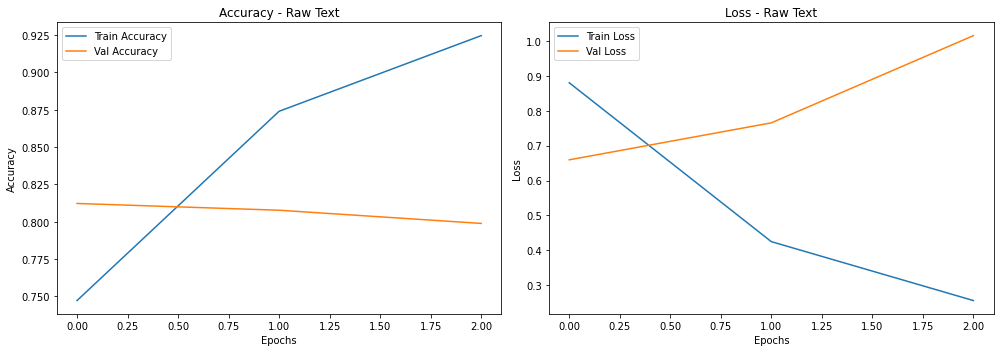

In [13]:
import matplotlib.pyplot as plt

def plot_learning_curves(history, title_suffix=""):
    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.title(f"Accuracy - {title_suffix}")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title(f"Loss - {title_suffix}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot learning curves for raw designation
plot_learning_curves(history_raw, title_suffix="Raw Text")


####  4.5.2 Evaluation Metrics: Weighted F1-Score, Precision & Recall

We evaluate the model's predictive performance using the following metrics:

- **Weighted F1-score**
- **Precision** 
- **Recall** 

These metrics provide a more complete evaluation than accuracy alone.


In [14]:
from sklearn.metrics import f1_score, precision_score, recall_score

def evaluate_model(model, X, y_true, label=""):
    y_pred = np.argmax(model.predict(X), axis=1)

    f1 = f1_score(y_true, y_pred, average="weighted")
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")

    print(f"\n Evaluation Metrics – {label}")
    print(f"   Weighted F1-score : {f1:.4f}")
    print(f"   Precision         : {precision:.4f}")
    print(f"   Recall            : {recall:.4f}")

# Run evaluation on validation set
evaluate_model(model_raw, X_val_raw_split, y_val_raw_split, label="Raw Text (Validation Set)")


531/531 [==============================] - 2s 3ms/step

 Evaluation Metrics – Raw Text (Validation Set)
   Weighted F1-score : 0.8121
   Precision         : 0.8245
   Recall            : 0.8122


#### 4.5.3 Detailed Classification Report

In [15]:
from sklearn.metrics import classification_report

def generate_classification_report(model, X, y_true, label=""):
    y_pred = np.argmax(model.predict(X), axis=1)
    report = classification_report(y_true, y_pred, digits=4)
    print(f"\n Classification Report – {label}")
    print(report)

# Exécution sur jeu de validation
generate_classification_report(model_raw, X_val_raw_split, y_val_raw_split, label="Raw Text (Validation Set)")


531/531 [==============================] - 2s 3ms/step

 Classification Report – Raw Text (Validation Set)
              precision    recall  f1-score   support

           0     0.7235    0.3676    0.4875       612
           1     0.7120    0.6929    0.7023       521
           2     0.8255    0.7423    0.7817       357
           3     0.8011    0.9006    0.8480       161
           4     0.6867    0.8460    0.7581       539
           5     0.9648    0.9071    0.9351       786
           6     0.6507    0.6507    0.6507       146
           7     0.6888    0.6681    0.6783       961
           8     0.6105    0.4953    0.5469       424
           9     0.9646    0.9507    0.9576       974
          10     0.9394    0.9172    0.9281       169
          11     0.8842    0.7377    0.8043       507
          12     0.8336    0.7083    0.7659       672
          13     0.8325    0.8440    0.8382      1013
          14     0.8828    0.9132    0.8977       841
          15     0.9032    0

####  4.5.4 Confusion Matrix: Error Analysis

531/531 [==============================] - 2s 3ms/step


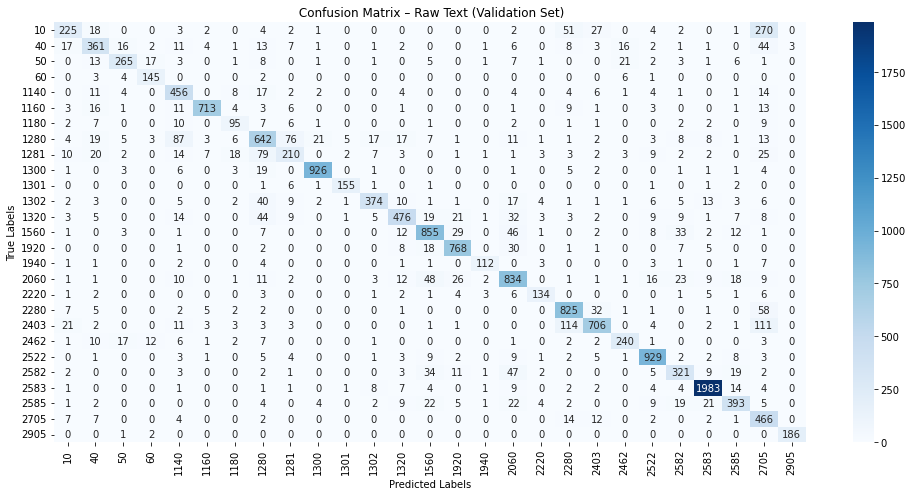

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, X, y_true, class_labels, label=""):
    y_pred = np.argmax(model.predict(X), axis=1)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(14, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(f" Confusion Matrix – {label}")
    plt.tight_layout()
    plt.show()

# Class labels from mapping (sorted by encoded index)
class_labels = [code for code, idx in sorted(prdtypecode_mapping.items(), key=lambda x: x[1])]

# Plot for validation predictions
plot_confusion_matrix(
    model_raw,
    X_val_raw_split,
    y_val_raw_split,
    class_labels=class_labels,
    label="Raw Text (Validation Set)"
)


### 4.6 Save Model – Iteration 1: Without Text Cleaning

In [17]:
# Reload config to ensure latest paths
importlib.reload(config)

# Save raw model
raw_model_path = Path(config.BENCHMARK_TEXT_MODEL_DIR) / "benchmark_cnn_raw_designation_model.h5"
model_raw.save(raw_model_path)

print(f"[✔] Model saved at: {raw_model_path}")


[✔] Model saved at: D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\models\text\benchmark\benchmark_cnn_raw_designation_model.h5


---

## 5. Iteration 2: With Text Cleaning

In this second experiment, we evaluate the impact of **text cleaning** on model performance.

We apply basic preprocessing to the `designation` field before tokenization:
- Lowercasing
- Removing punctuation and special characters
- Removing extra spaces

Then we re-tokenize, re-pad, and re-train the same CNN architecture on the cleaned text.


### 5.1 Clean the designation Text

In [18]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
df_train_full["designation_cleaned"] = df_train_full["designation"].astype(str).apply(clean_text)

# Sanity check
print("Sample cleaned training text:")
display(df_train_full[["designation", "designation_cleaned"]].head())


Sample cleaned training text:


,designation,designation_cleaned
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,olivia personalisiertes notizbuch 150 seiten p...
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,journal des arts le n 133 du 28092001 lart et ...
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,grand stylet ergonomique bleu gamepad nintendo...
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,peluche donald europe disneyland 2000 marionne...
4,La Guerre Des Tuques,la guerre des tuques


### 5.2 Tokenization & Padding (Cleaned Text)

We now tokenize the cleaned `designation` text using the same approach:

- `Tokenizer(num_words=20000)` → limits the vocabulary  
- `pad_sequences(maxlen=34)` → ensures fixed-length input sequences

This step prepares input data for training the CNN on cleaned text.


In [19]:
# Reuse same tokenizer setup
tokenizer_cleaned = Tokenizer(num_words=VOCAB_SIZE)
tokenizer_cleaned.fit_on_texts(df_train_full["designation_cleaned"])

# Tokenize and pad
X_cleaned_full = pad_sequences(
    tokenizer_cleaned.texts_to_sequences(df_train_full["designation_cleaned"]),
    maxlen=MAX_SEQUENCE_LENGTH
)

print("[✔] Cleaned Tokenization complete.")
print(f" X_cleaned_full shape: {X_cleaned_full.shape}")


[✔] Cleaned Tokenization complete.
 X_cleaned_full shape: (84916, 34)


### 5.3 Train/Validation Split + EarlyStopping Callback (Cleaned Text)

In [20]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

# Split cleaned input
X_train_cleaned_split, X_val_cleaned_split, y_train_cleaned_split, y_val_cleaned_split = train_test_split(
    X_cleaned_full,
    y_train_raw,
    test_size=0.2,
    random_state=42
)

print(f"X_train_cleaned_split shape: {X_train_cleaned_split.shape}")
print(f"X_val_cleaned_split shape  : {X_val_cleaned_split.shape}")

# EarlyStopping config
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)


X_train_cleaned_split shape: (67932, 34)
X_val_cleaned_split shape  : (16984, 34)


### 5.4 Initialize & Train CNN Benchmark Model (Cleaned Text)

In [21]:
# Sanity check on target labels before training
print("y_train_raw sample:", y_train_raw[:10])
print(f"Min label: {y_train_raw.min()}, Max label: {y_train_raw.max()}")
print(f"Unique encoded labels: {np.unique(y_train_raw)}")


y_train_raw sample: [ 0 18  2  7 25 18  0 21  7 22]
Min label: 0, Max label: 26
Unique encoded labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26]


In [22]:
# Initialize model (same architecture)
model_cleaned = create_cnn_text_model()

# Train on cleaned text
history_cleaned = model_cleaned.fit(
    X_train_cleaned_split,
    y_train_cleaned_split,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_cleaned_split, y_val_cleaned_split),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
2123/2123 [==============================] - 649s 305ms/step - loss: 0.9211 - accuracy: 0.7339 - val_loss: 0.7317 - val_accuracy: 0.7763
Epoch 2/10
2123/2123 [==============================] - 678s 320ms/step - loss: 0.4626 - accuracy: 0.8615 - val_loss: 0.7951 - val_accuracy: 0.7880
Epoch 3/10
2123/2123 [==============================] - 680s 320ms/step - loss: 0.2835 - accuracy: 0.9141 - val_loss: 1.0305 - val_accuracy: 0.7822
Epoch 3: early stopping


### 5.5 Evaluation – Cleaned Text

#### 5.5.1 Plot Learning Curves – Cleaned Text

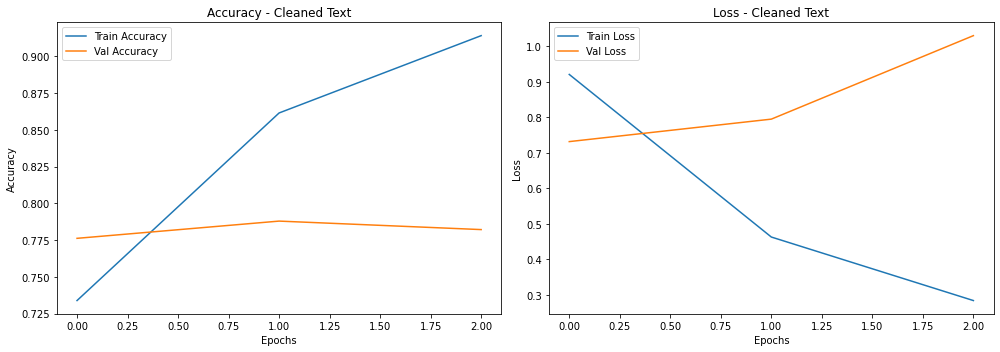

In [23]:
# Plot training curves for cleaned text input
plot_learning_curves(history_cleaned, title_suffix="Cleaned Text")


#### 5.5.2 Evaluation Metrics: Weighted F1-Score, Precision & Recall

In [24]:
evaluate_model(model_cleaned, X_val_cleaned_split, y_val_cleaned_split, label="Cleaned Text")

531/531 [==============================] - 2s 3ms/step

 Evaluation Metrics – Cleaned Text
   Weighted F1-score : 0.7825
   Precision         : 0.8065
   Recall            : 0.7763


#### 5.5.3 Detailed Classification Report

In [25]:
generate_classification_report(model_cleaned, X_val_cleaned_split, y_val_cleaned_split, label="Cleaned Text")


531/531 [==============================] - 2s 3ms/step

 Classification Report – Cleaned Text
              precision    recall  f1-score   support

           0     0.3593    0.7467    0.4851       612
           1     0.8277    0.5624    0.6697       521
           2     0.8454    0.7507    0.7953       357
           3     0.8512    0.8882    0.8693       161
           4     0.7532    0.7588    0.7560       539
           5     0.8675    0.9415    0.9030       786
           6     0.7119    0.5753    0.6364       146
           7     0.4642    0.6941    0.5563       961
           8     0.5406    0.5024    0.5208       424
           9     0.8913    0.6396    0.7448       974
          10     0.8876    0.8876    0.8876       169
          11     0.8853    0.7002    0.7819       507
          12     0.7789    0.7128    0.7444       672
          13     0.9149    0.7532    0.8262      1013
          14     0.8917    0.9108    0.9012       841
          15     0.8790    0.7956    0.83

#### 5.5.4 Confusion Matrix: Error Analysis

531/531 [==============================] - 2s 3ms/step


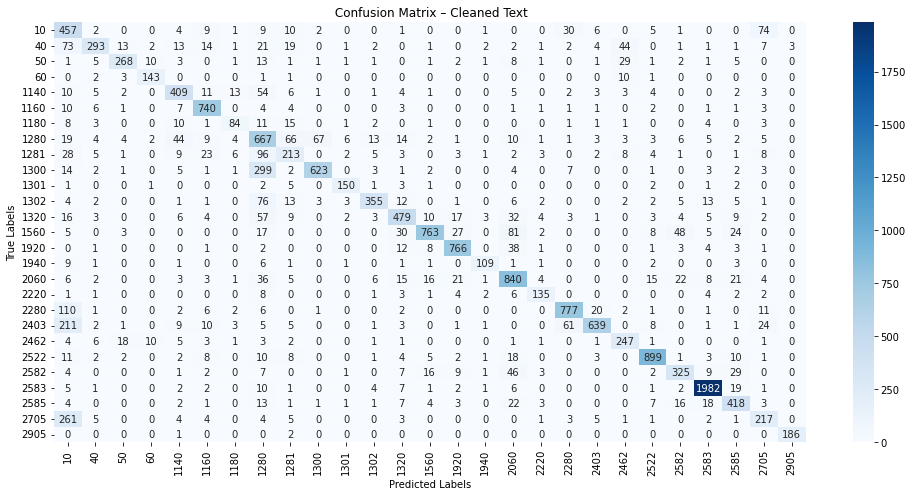

In [26]:
plot_confusion_matrix(model_cleaned, X_val_cleaned_split, y_val_cleaned_split, class_labels, label="Cleaned Text")


### 5.6 Save Model – Iteration 2: With Text Cleaning

In [27]:
# Reload config again if needed
importlib.reload(config)

# Save cleaned model
cleaned_model_path = Path(config.BENCHMARK_TEXT_MODEL_DIR) / "benchmark_cnn_cleaned_designation_model.h5"
model_cleaned.save(cleaned_model_path)

print(f"[✔] Model saved at: {cleaned_model_path}")


[✔] Model saved at: D:\Data_Science\Append_Data_Engineer_AWS_MLOPS\Data_Scientist_Rakuten_Project-main\models\text\benchmark\benchmark_cnn_cleaned_designation_model.h5


---

# 6. Benchmark Results

## Results: Raw Text Model
- **Benchmark F1-score (given)**: `0.8113`
- **Our Model F1-score**: `0.8121`  
- **Precision**: `0.8245` 
- **Recall**: `0.8122` 

##  Results: Cleaned Text Model
- **Benchmark F1-score (given)**: `0.8113`
- **Our Model F1-score**: `0.7825`  
- **Precision**: `0.8065` 
- **Recall**: `0.7763` 

## Obervations 
The model trained on **raw text** slightly outperformed the benchmark, achieving a **F1-score of 0.8121**.  
In contrast, the **cleaned text version performed worse** (`F1-score: 0.7825`), which suggests that keeping the original wording—even if noisy—was more helpful for the CNN model.

This shows that **preprocessing is not always better** and should be tested carefully depending on the task and model.



# 7.   🔄 Next Steps
In this notebook, we replicated the **CNN benchmark model** from the Rakuten Challenge using only the `designation` field.  
Our raw text model **outperformed** the official benchmark (F1-score: **0.8121** vs **0.8113**), while the cleaned text version showed a drop in performance.

This suggests that for this dataset, preserving the original structure of the product titles—even with some noise—can lead to better classification results.

---

##  What’s Next?

Now that we have established a strong CNN baseline, we will:

- **Train classic Machine Learning models** (e.g., Logistic Regression, Random Forest, XGBoost) using **TF-IDF features** extracted from the text.
-  **Experiment with Deep Learning architectures** such as **RNN**, **LSTM**, and **GRU** o better capture sequential structure in the text.
